In [14]:
# --- All imports collected and organized at the top ---
# Core scientific libraries
import os 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # Disable XLA preallocation to prevent OOM errors
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"  # Limit XLA to use at most 80% of GPU memory

import numpy as np
import matplotlib.pyplot as plt
import unxt as u
from matplotlib.colors import TwoSlopeNorm

import jax 

# Pyramid core imports
import pyramid as pr
from pyramid.magcreator.shapes import disc
from pyramid.magcreator.magcreator import create_mag_dist_homog
from pyramid.fielddata import VectorData
from pyramid.projector import SimpleProjector
from pyramid.phasemapper import PhaseMapperRDFC
from pyramid.utils.convenience import reconstruction_2d_from_phasemap
from pyramid.phasemap import PhaseMap
from pyramid.kernel import Kernel

# LiberTEM-holo MBIR imports
from libertem_holo.base.mbir import (
    forward_model_2d,
    lcurve_sweep_vmap,
    reconstruct_2d,
 )


def array_value(value):
    if isinstance(value, u.Quantity):
        return np.asarray(value.value)
    return np.asarray(value)


jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision in JAX

%matplotlib widget

# Synthetic Magnetisation Reconstruction with Pyramid
This notebook demonstrates the workflow for generating a synthetic magnetisation distribution, simulating phase maps, and reconstructing the magnetisation using the Pyramid library.

---


In [15]:
N = 128
dim = (N, N, N)
center = (N//2, N//2, N//2)
R = 40
H = 17
px_size = 7.423
pixel_size = u.Quantity(px_size, "nm")
mag_shape = disc(dim=dim, center=center, radius=R, height=H)
disc_uni = create_mag_dist_homog(mag_shape=mag_shape, phi=np.pi/2)
b_0 = 1.0
max_iter = 1000

## 1. Create Synthetic Magnetisation Distribution
We define a synthetic disc-shaped magnetisation distribution for testing.

In [16]:
mag_distrib = VectorData(a=px_size, field=disc_uni)

### Visualize Magnetisation Components
Display the three components of the synthetic magnetisation in the central slice.

Text(0.5, 1.0, '$M_z$ (central slice)')

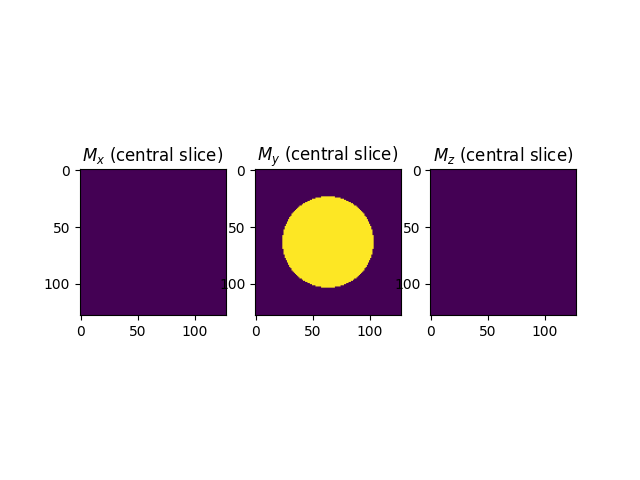

In [17]:
fig, ax = plt.subplots(ncols=3)

ax[0].imshow(mag_distrib.field[0, N//2, ...], vmin=0.0, vmax=1.0)
ax[0].set_title("$M_x$ (central slice)")
ax[1].imshow(mag_distrib.field[1, N//2, ...], vmin=0.0, vmax=1.0)
ax[1].set_title("$M_y$ (central slice)")
ax[2].imshow(mag_distrib.field[2, N//2, ...], vmin=0.0, vmax=1.0)
ax[2].set_title("$M_z$ (central slice)")

In [18]:
projector = SimpleProjector(mag_distrib.dim, axis='z')
kern = Kernel(mag_distrib.a, projector.dim_uv, b_0=b_0, geometry="disc")
phasemapper = PhaseMapperRDFC(kern)
field_proj = projector(mag_distrib)
phasemap = phasemapper(field_proj)
phasemap.mask = field_proj.get_mask()[0, ...]

## 2. Simulate Phase Map
Project the synthetic magnetisation and simulate the phase map using the forward model.

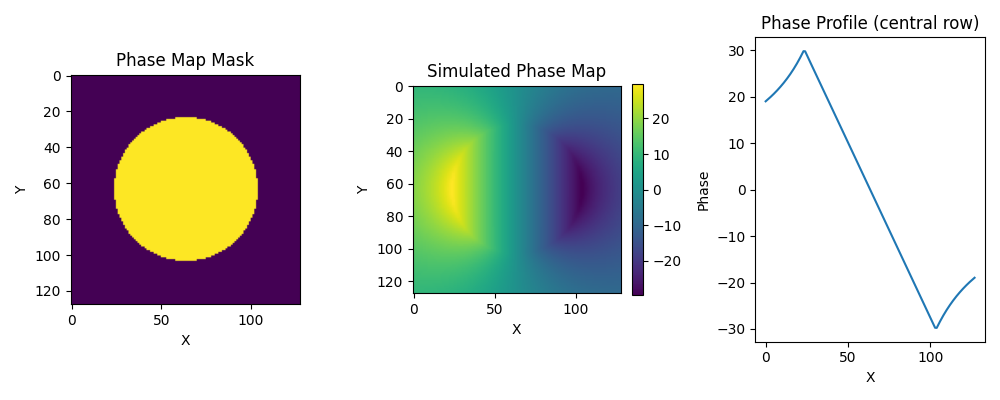

In [19]:
fig, ax = plt.subplots(ncols=3, figsize=(10,4))

ax[0].imshow(phasemap.mask)
ax[0].set_title("Phase Map Mask")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")

im1 = ax[1].imshow(phasemap.phase)
ax[1].set_title("Simulated Phase Map")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

ax[2].plot(phasemap.phase[N//2, ...])
ax[2].set_title("Phase Profile (central row)")
ax[2].set_xlabel("X")
ax[2].set_ylabel("Phase")

plt.tight_layout()

### Visualize Phase Map and Mask
Show the simulated phase map and the mask used for further processing.

In [20]:
phase_mag = phasemap.phase
phase_mip = phasemap.mask

Mask covers 5024 / 16384 pixels (30.7%)


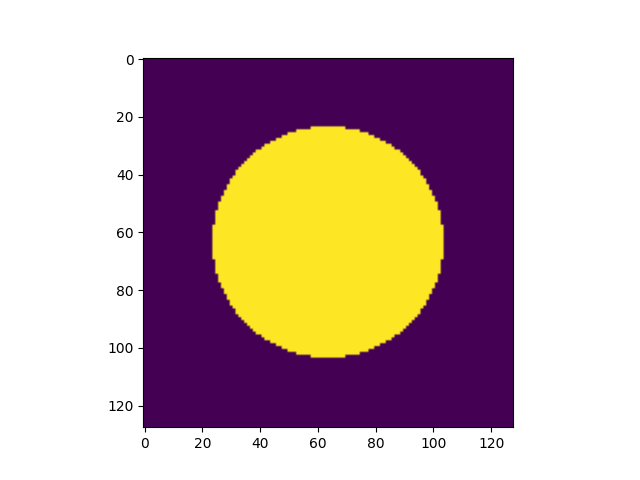

In [21]:
mip_threshold = 0.1
mask = (np.abs(phase_mip) > mip_threshold).astype(np.float64)
plt.figure()
plt.imshow(mask)
print(f"Mask covers {mask.sum():.0f} / {mask.size} pixels "
      f"({100 * mask.mean():.1f}%)")

phasemap = pr.PhaseMap(a=px_size, phase=phase_mag, mask=mask)
dim = (1,) + phasemap.dim_uv

# Pass the disc mask to DataSet so Pyramid optimizes only inside the disc,
# matching MBIR's `mag * mask` behaviour.  Without this, Pyramid defaults to
# an all-True mask (full grid) which gives very different L-curve values.
mask_3d = mask.astype(bool)[None, ...]  # shape (1, H, W)
data_set = pr.DataSet(phasemap.a, dim=dim, b_0=b_0, mask=mask_3d)

# Pass a PhaseMapperRDFC explicitly so Pyramid's ForwardModel uses the same
# forward model as MBIR (zero-padded linear convolution, not periodic FDFC).
kern_pyr_rdfc = Kernel(px_size, phasemap.dim_uv, b_0=b_0, geometry="disc")
phasemapper_rdfc = PhaseMapperRDFC(kern_pyr_rdfc)
data_set.append(phasemap, pr.SimpleProjector(dim=dim), phasemapper=phasemapper_rdfc)

## 3. Prepare Data for Reconstruction
Apply a mask to the phase map and prepare the dataset for the forward model.

In [22]:
ramp_order = 1
fwd_model = pr.ForwardModel(data_set, ramp_order=ramp_order)

## 4. Forward Model and L-Curve Analysis
Set up the forward model and perform L-curve analysis to select the regularization parameter.

  0%|          | 0/5 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

<Axes: xlabel='$\\Vert\\mathbf{F}(\\mathbf{x})-\\mathbf{y}\\Vert_{\\mathbf{S}_{\\epsilon}^{-1}}^{2}$', ylabel='$\\frac{1}{\\lambda}\\Vert\\mathbf{x}\\Vert_{\\mathbf{S}_{a}^{-1}}^{2}$'>

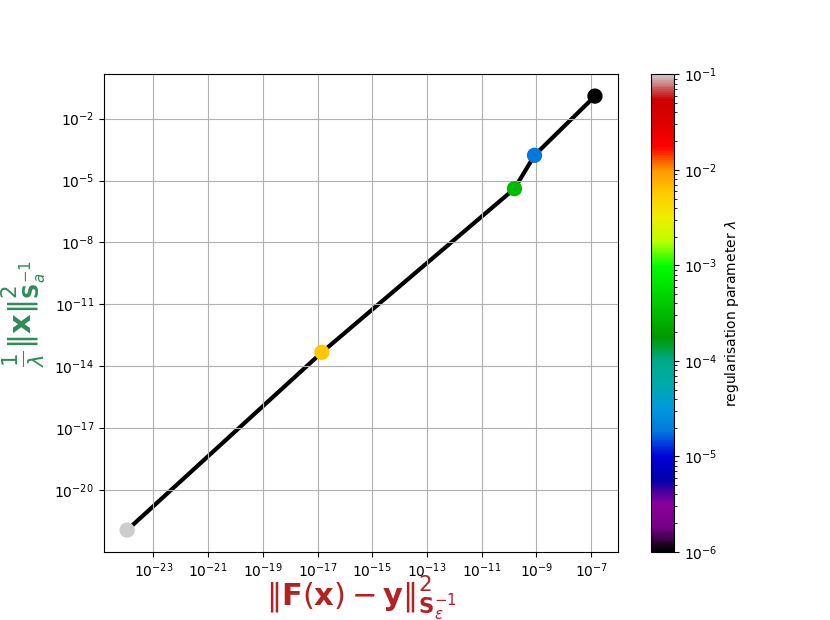

In [23]:
lambdas = np.logspace(-6, -1, num=5)
lcurve = pr.LCurve(fwd_model, max_iter=max_iter, save_dir=None)

lcurve.calculate(lambdas)

x_lcurve_pyramid = [lcurve.l_dict[lam][0] for lam in lambdas]
y_lcurve_pyramid = [lcurve.l_dict[lam][1] / lam for lam in lambdas]

lcurve.plot(lambdas)

## 5. 2D Reconstruction from Phase Map
Use the selected regularization parameter to reconstruct the 2D magnetisation distribution from the phase map.

In [24]:
best_lam = 1e-4

pm = PhaseMap(a=px_size, phase=np.asarray(phase_mag), mask=mask)
magdata_pyr, cost_pyr = reconstruction_2d_from_phasemap(
    pm, b_0=b_0, lam=best_lam, max_iter=max_iter,
    ramp_order=None, verbose=True,
    )

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

In [25]:
u_pyr = magdata_pyr.field[0,0,...]
v_pyr = magdata_pyr.field[1,0,...]
mag_abs_pyr = magdata_pyr.field_amp[0,...]

### Extract Magnetisation Components
Extract the reconstructed $M_x$, $M_y$, and $|M|$ components from the result.

### Normalization Check for Pyramid Reconstruction
To ensure Pyramid's reconstructed magnetization is correctly normalized, the following points are critical:
- The synthetic phase and the reconstruction must use the same forward model (e.g., both RDFC).
- The mask must cover the full region of nonzero magnetization.
- The expected projected $|M|$ is the sum of per-voxel $|M|$ along the projection axis (e.g., height $H$ for a disc with $|M|=1$ per voxel).
- All physical parameters (voxel size, $b_0$, etc.) must be consistent.

The next cell prints the mean and max $|M|$ inside the mask and compares to the expected value.

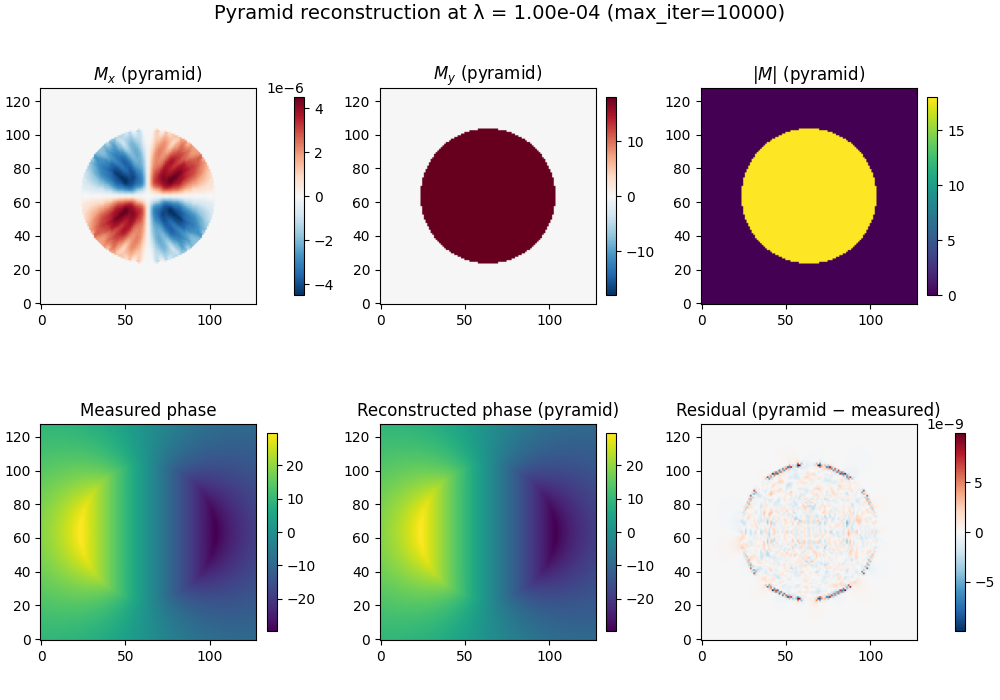

Pyramid residual RMS: 0.000000


In [26]:
# Pyramid result: same 2×3 layout as libertem_holo

# Forward-model pyramid's reconstruction to get predicted phase
kern_pyr = Kernel(px_size, phase_mag.shape, b_0=b_0, geometry="disc")
mapper_pyr = PhaseMapperRDFC(kern_pyr)
field_pyr = np.zeros((3, 1) + phase_mag.shape)
field_pyr[0, 0] = u_pyr
field_pyr[1, 0] = v_pyr
pred_pyr = mapper_pyr(VectorData(px_size, field_pyr)).phase
residual_pyr = pred_pyr - phase_mag

fig, axs = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)

# Row 1: magnetisation components

vmax_u = max(np.abs(u_pyr).max(), 1e-12)
vmax_v = max(np.abs(v_pyr).max(), 1e-12)

im = axs[0, 0].imshow(u_pyr, cmap="RdBu_r", origin="lower",
                        norm=TwoSlopeNorm(0, -vmax_u, vmax_u))
axs[0, 0].set_title(r"$M_x$ (pyramid)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(v_pyr, cmap="RdBu_r", origin="lower",
                        norm=TwoSlopeNorm(0, -vmax_v, vmax_v))
axs[0, 1].set_title(r"$M_y$ (pyramid)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[0, 2].imshow(mag_abs_pyr, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (pyramid)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

# Row 2: phase comparison
vmin_p = min(np.nanmin(phase_mag), np.nanmin(pred_pyr))
vmax_p = max(np.nanmax(phase_mag), np.nanmax(pred_pyr))

im = axs[1, 0].imshow(phase_mag, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(pred_pyr, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 1].set_title("Reconstructed phase (pyramid)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)

dmax_p = max(np.abs(residual_pyr).max(), 1e-12)
im = axs[1, 2].imshow(residual_pyr, cmap="RdBu_r", origin="lower", vmin=-dmax_p, vmax=dmax_p)
axs[1, 2].set_title("Residual (pyramid − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(f"Pyramid reconstruction at λ = {best_lam:.2e} (max_iter=10000)", fontsize=14)
plt.show()

print(f"Pyramid residual RMS: {np.sqrt(np.mean(residual_pyr**2)):.6f}")
#print(f"LT-holo residual RMS: {np.sqrt(np.mean((np.asarray(pred_phase) - mag_phase)**2)):.6f}")

## 7. MBIR Solution with LiberTEM-holo
Now we reconstruct the magnetisation using the MBIR method from `libertem_holo.base.mbir` and compare it to the Pyramid solution.

In [27]:
lambdas_mbir = u.Quantity(np.logspace(-6, 2, num=10), "rad2")
lc_mbir = lcurve_sweep_vmap(
    phase=u.Quantity(phase_mag, "rad"),
    mask=mask,
    pixel_size=pixel_size,
    lambdas=lambdas_mbir,
    solver="newton_cg",
    pyramid_compat=True,
)

corner_lambda = lc_mbir.lambdas[lc_mbir.corner_index]
print(
    f"MBIR L-curve corner: index {lc_mbir.corner_index} "
    f"(lambda = {float(corner_lambda.value):.3e})"
 )

MBIR L-curve corner: index 5 (lambda = 2.783e-02)


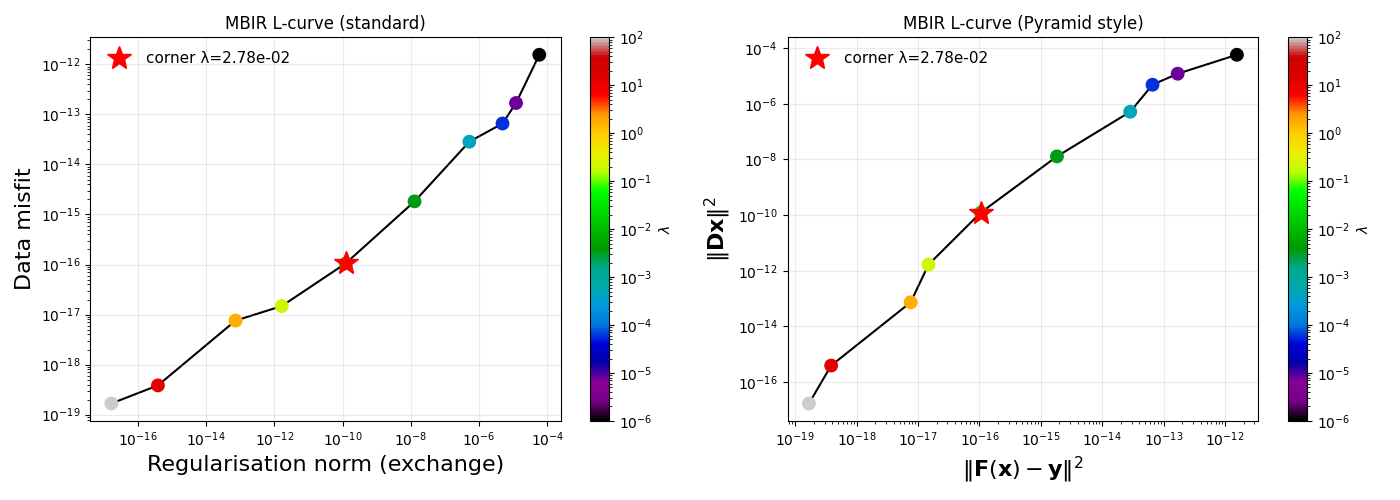

In [28]:
# --- Plot MBIR L-curve (standard and Pyramid style) ---
from libertem_holo.base import mbir as mbir_mod
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
mbir_mod.plot_lcurve(lc_mbir, pyramid_style=False, ax=axs[0])
axs[0].set_title("MBIR L-curve (standard)")
mbir_mod.plot_lcurve(lc_mbir, pyramid_style=True, ax=axs[1])
axs[1].set_title("MBIR L-curve (Pyramid style)")
plt.tight_layout()
plt.show()

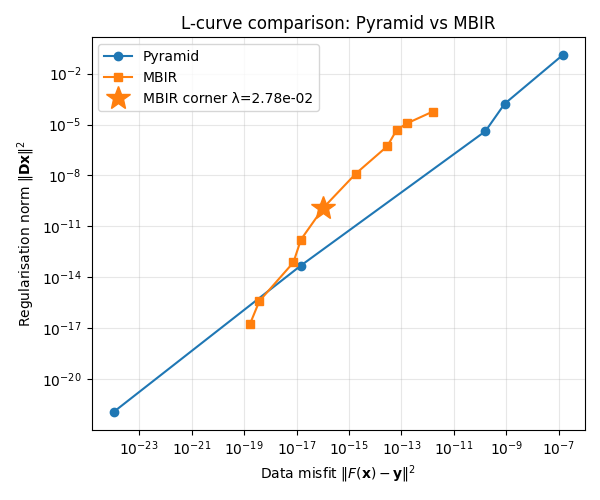

In [29]:
# --- Overlay L-curve comparison: Pyramid vs MBIR ---
fig, ax = plt.subplots(figsize=(6, 5))

mbir_data_misfits = array_value(lc_mbir.data_misfits)
mbir_reg_norms = array_value(lc_mbir.reg_norms)
mbir_lambdas = array_value(lc_mbir.lambdas)

# Pyramid L-curve (x = data misfit, y = reg norm)
ax.loglog(x_lcurve_pyramid, y_lcurve_pyramid, 'o-', color='tab:blue', label='Pyramid')

# MBIR L-curve (pyramid_compat=True → forward_diff_norm, same metric)
ax.loglog(mbir_data_misfits, mbir_reg_norms, 's-', color='tab:orange', label='MBIR')

# Mark corners
corner_idx_pyr = lcurve.corner_idx if hasattr(lcurve, 'corner_idx') else None
corner_idx_mbir = lc_mbir.corner_index

if corner_idx_mbir is not None:
    ax.plot(
        mbir_data_misfits[corner_idx_mbir],
        mbir_reg_norms[corner_idx_mbir],
        '*',
        ms=18,
        color='tab:orange',
        zorder=5,
        label=f'MBIR corner λ={mbir_lambdas[corner_idx_mbir]:.2e}'
    )

ax.set_xlabel(r'Data misfit $\|F(\mathbf{x}) - \mathbf{y}\|^2$')
ax.set_ylabel(r'Regularisation norm $\|\mathbf{Dx}\|^2$')
ax.set_title('L-curve comparison: Pyramid vs MBIR')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Visualize LiberTEM-holo Reconstruction
Reconstruct with the MBIR corner lambda and plot the recovered projected magnetisation together with the predicted phase and residual.

Best MBIR lambda: 2.783e-02
Projected |M| mean inside mask: 18.0000
Projected |M| max inside mask:  18.0000
MBIR residual RMS: 0.000000


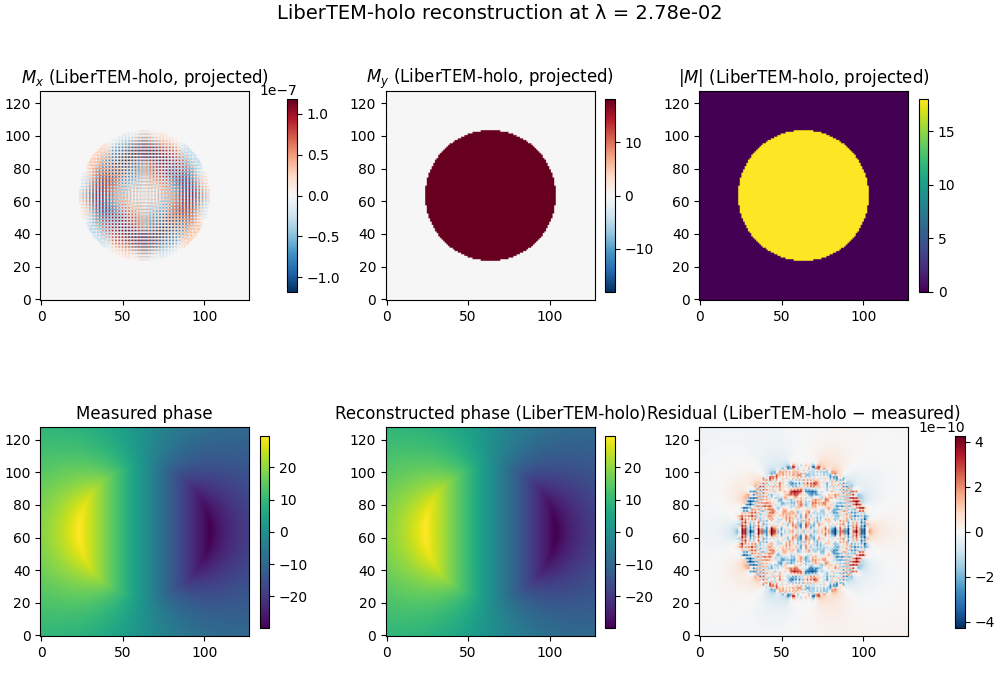

In [31]:
best_lam_mbir = lc_mbir.lambdas[lc_mbir.corner_index]
result_mbir = reconstruct_2d(
    phase=u.Quantity(phase_mag, "rad"),
    pixel_size=pixel_size,
    mask=mask,
    lam=best_lam_mbir,
    solver="newton_cg",
)

best_mag_mbir = array_value(result_mbir.magnetization)
mx_mbir = best_mag_mbir[..., 0]
my_mbir = best_mag_mbir[..., 1]
mag_norm_mbir = np.sqrt(mx_mbir**2 + my_mbir**2)

pred_phase_mbir = array_value(
    forward_model_2d(
        result_mbir.magnetization,
        pixel_size,
        ramp_coeffs=result_mbir.ramp_coeffs,
    )
)
residual_mbir = pred_phase_mbir - phase_mag

inside = mask > 0.5
print(f"Best MBIR lambda: {float(best_lam_mbir.value):.3e}")
print(f"Projected |M| mean inside mask: {mag_norm_mbir[inside].mean():.4f}")
print(f"Projected |M| max inside mask:  {mag_norm_mbir[inside].max():.4f}")
print(f"MBIR residual RMS: {np.sqrt(np.mean(residual_mbir**2)):.6f}")

fig, axs = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)

vmax_mx = max(np.abs(mx_mbir).max(), 1e-12)
vmax_my = max(np.abs(my_mbir).max(), 1e-12)

im = axs[0, 0].imshow(
    mx_mbir,
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0, -vmax_mx, vmax_mx),
)
axs[0, 0].set_title(r"$M_x$ (LiberTEM-holo, projected)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(
    my_mbir,
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0, -vmax_my, vmax_my),
)
axs[0, 1].set_title(r"$M_y$ (LiberTEM-holo, projected)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[0, 2].imshow(mag_norm_mbir, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (LiberTEM-holo, projected)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

vmin_m = min(np.nanmin(phase_mag), np.nanmin(pred_phase_mbir))
vmax_m = max(np.nanmax(phase_mag), np.nanmax(pred_phase_mbir))

im = axs[1, 0].imshow(
    phase_mag,
    cmap="viridis",
    origin="lower",
    vmin=vmin_m,
    vmax=vmax_m,
 )
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(
    pred_phase_mbir,
    cmap="viridis",
    origin="lower",
    vmin=vmin_m,
    vmax=vmax_m,
 )
axs[1, 1].set_title("Reconstructed phase (LiberTEM-holo)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)

dmax_m = max(np.abs(residual_mbir).max(), 1e-12)
im = axs[1, 2].imshow(
    residual_mbir,
    cmap="RdBu_r",
    origin="lower",
    vmin=-dmax_m,
    vmax=dmax_m,
 )
axs[1, 2].set_title("Residual (LiberTEM-holo − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(
    f"LiberTEM-holo reconstruction at λ = {float(best_lam_mbir.value):.2e}",
    fontsize=14,
 )
plt.show()